# OCR MASIVO DE IMÁGENES EN GOOGLE DRIVE
Extrae texto de certificados médicos (.jpeg y .jpg)

# 1. Set de Imágenes

In [2]:
!pip install easyocr pandas openpyxl -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 40.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 299.6/299.6 kB 19.3 MB/s eta 0:00:00


In [ ]:
# 2. IMPORTAR ----------
import easyocr
import pandas as pd
import spacy
from pathlib import Path
import os

In [ ]:
from google.colab import drive
# 3. MONTAR GOOGLE DRIVE ----------
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 4. RUTA DE LA CARPETA ----------
CARPETA_IMAGENES = "/content/drive/MyDrive/2026-1/Ciencia de Datos 2/PARCIAL/CM_Imagenes"

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import random

# Extensiones válidas
extensiones = [".jpg", ".jpeg", ".png"]

# Obtener imágenes
imagenes = [
    str(x) for x in Path(CARPETA_IMAGENES).glob("*")
    if x.suffix.lower() in extensiones]

print(f"Se encontraron {len(imagenes)} imágenes")

Se encontraron 31 imágenes


In [ ]:
fig, axes = plt.subplots(11, 3, figsize=(15, 55))
axes = axes.flatten()

# Mostrar imágenes
for ax, img_path in zip(axes, imagenes):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(Path(img_path).name, fontsize=8)
    ax.axis("off")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

# 2. PRE PROCESAMIENTO

## 2.a. Preprocesamiengo general
Preprocesamiento general, adecuado para todo tipo de imágenes.
 1. Auto-rotación
 2. Resize moderado
3. Conversión a grayscale

In [ ]:
!pip install opencv-python pillow -q
import cv2
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import os

In [ ]:
# Carpeta salida
CARPETA_SALIDA = "/content/drive/MyDrive/2026-1/Ciencia de Datos 2/PARCIAL/CM_Imagenes_Preprocesadas"

os.makedirs(CARPETA_SALIDA, exist_ok=True)


In [ ]:
# =========================================================
# FUNCIÓN AUTO-ROTACIÓN
# =========================================================

def corregir_rotacion(img):

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Invertir para detectar texto
    gray = cv2.bitwise_not(gray)

    # Threshold
    thresh = cv2.threshold(
        gray,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )[1]

    # Coordenadas del texto
    coords = np.column_stack(np.where(thresh > 0))

    # Si no detecta texto suficiente
    if len(coords) < 100:
        return img

    # Ángulo mínimo
    angle = cv2.minAreaRect(coords)[-1]

    # Ajuste ángulo OpenCV
    if angle < -45:
        angle = -(90 + angle)
    else:
        angle = -angle

    # Si ya está casi recta, no rotar
    if abs(angle) < 1:
        return img

    # Rotar
    (h, w) = img.shape[:2]
    center = (w // 2, h // 2)

    M = cv2.getRotationMatrix2D(center, angle, 1.0)

    rotated = cv2.warpAffine(
        img,
        M,
        (w, h),
        flags=cv2.INTER_CUBIC,
        borderMode=cv2.BORDER_REPLICATE
    )

    return rotated

# =========================================================
# PROCESAR TODAS LAS IMÁGENES
# =========================================================

for i, img_path in enumerate(imagenes):

    print(f"Procesando {i+1}/{len(imagenes)}")
    print(os.path.basename(img_path))

    # Leer imagen
    img = cv2.imread(img_path)

    if img is None:
        print("Error leyendo imagen")
        continue

    # A. AUTO-ROTACIÓN
    img = corregir_rotacion(img)

    # B. RESIZE MODERADO
    scale = 1.5

    width = int(img.shape[1] * scale)
    height = int(img.shape[0] * scale)

    img = cv2.resize(
        img,
        (width, height),
        interpolation=cv2.INTER_CUBIC
    )

    # C. GRAYSCALE
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # GUARDAR
    nombre = os.path.basename(img_path)

    output_path = os.path.join(
        CARPETA_SALIDA,
        nombre
    )

    cv2.imwrite(output_path, gray)

print("\nPREPROCESAMIENTO FINALIZADO")
print(f"Imágenes guardadas en:\n{CARPETA_SALIDA}")



Procesando 1/31
certificado_010.jpeg
Procesando 2/31
certificado_026.jpg
Procesando 3/31
certificado_025.jpg
Procesando 4/31
certificado_015.jpeg
Procesando 5/31
certificado_019.jpg
Procesando 6/31
certificado_023.jpg
Procesando 7/31
certificado_004.jpeg
Procesando 8/31
certificado_029.jpg
Procesando 9/31
certificado_017.jpg
Procesando 10/31
certificado_020.jpg
Procesando 11/31
certificado_006.jpeg
Procesando 12/31
certificado_024.jpg
Procesando 13/31
certificado_005.jpeg
Procesando 14/31
certificado_021.jpg
Procesando 15/31
certificado_002.jpeg
Procesando 16/31
certificado_031.jpg
Procesando 17/31
certificado_030.jpg
Procesando 18/31
certificado_013.jpeg
Procesando 19/31
certificado_014.jpeg
Procesando 20/31
certificado_011.jpeg
Procesando 21/31
certificado_008.jpeg
Procesando 22/31
certificado_007.jpg
Procesando 23/31
certificado_022.jpg
Procesando 24/31
certificado_012.jpeg
Procesando 25/31
certificado_018.jpg
Procesando 26/31
certificado_003.jpeg
Procesando 27/31
certificado_009.jp

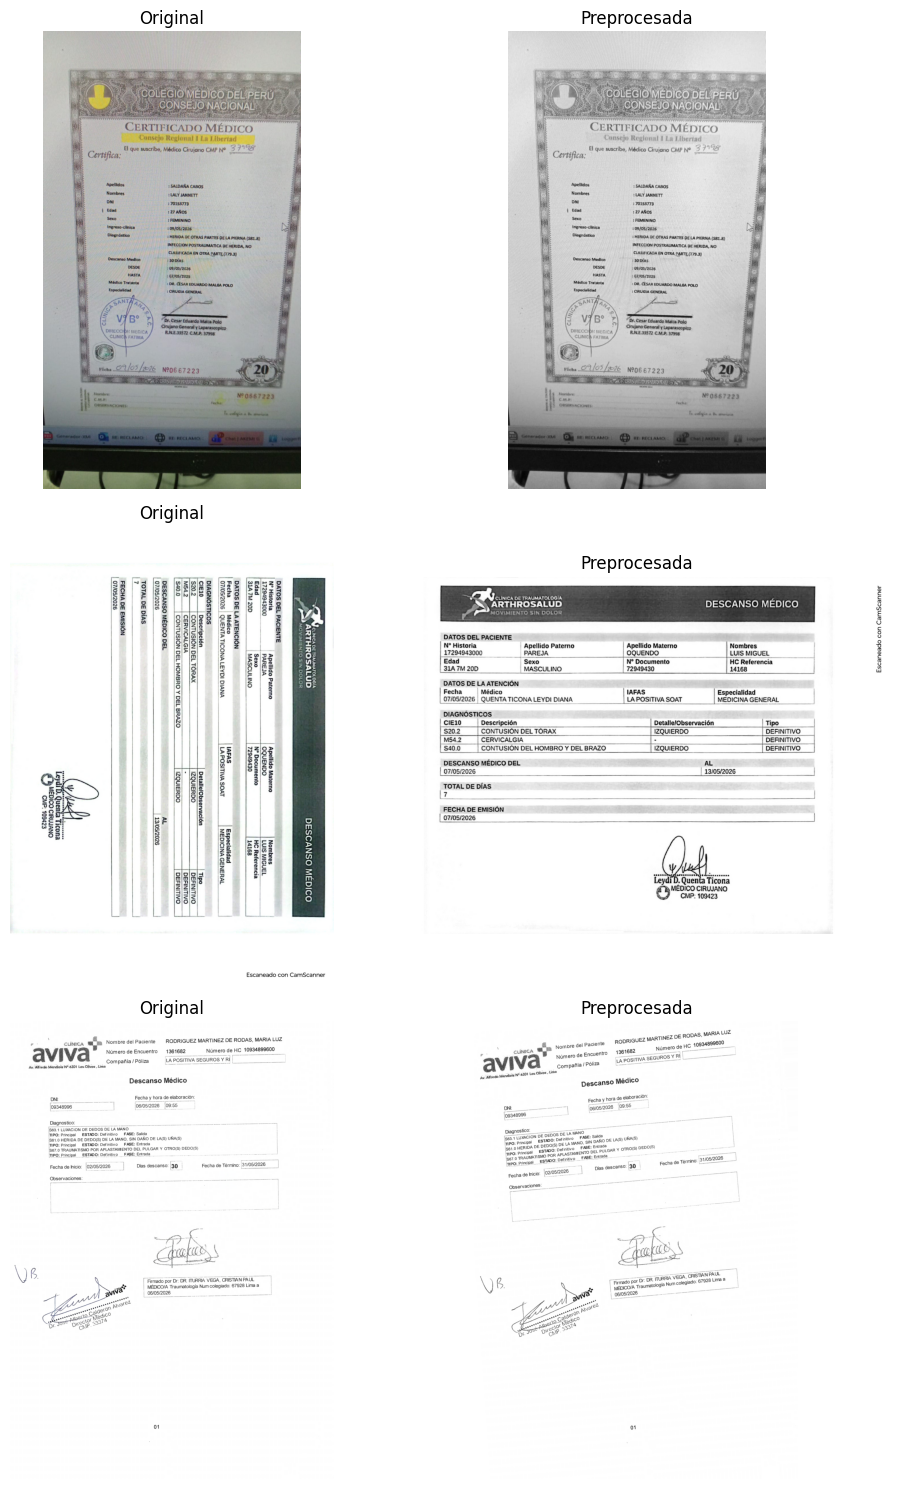

In [ ]:
# =========================================================
# MOSTRAR EJEMPLOS
# =========================================================

muestra = imagenes[3:6]

fig, axes = plt.subplots(len(muestra), 2, figsize=(10, 15))

for i, img_path in enumerate(muestra):

    original = Image.open(img_path)

    procesada_path = os.path.join(
        CARPETA_SALIDA,
        os.path.basename(img_path)
    )

    procesada = Image.open(procesada_path)

    axes[i, 0].imshow(original)
    axes[i, 0].set_title("Original")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(procesada, cmap="gray")
    axes[i, 1].set_title("Preprocesada")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## 2.b. Preprocesamiengo específico

Ahora se tomarán medidas de las imagénes para personalizar el preprocesamiento según lo que cada una necesita.

 Este bloque mide:
 - brillo
 - contraste
 - blur
 - orientación
 - tamaño
 - porcentaje blanco



In [ ]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path
import os

# =========================================================
# CARPETA DE IMÁGENES PREPROCESADAS
# =========================================================

CARPETA_PREPROCESADAS = "/content/drive/MyDrive/2026-1/Ciencia de Datos 2/PARCIAL/CM_Imagenes_Preprocesadas"

# =========================================================
# LISTAR IMÁGENES
# =========================================================

extensiones = [".jpg", ".jpeg", ".png"]

imagenes = [
    str(x) for x in Path(CARPETA_PREPROCESADAS).glob("*")
    if x.suffix.lower() in extensiones
]

print(f"Se encontraron {len(imagenes)} imágenes")

# =========================================================
# FUNCIÓN PARA EXTRAER MÉTRICAS
# =========================================================

def analizar_imagen(img_path):

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        return None

    # -----------------------------------------------------
    # TAMAÑO
    # -----------------------------------------------------

    alto, ancho = img.shape

    # -----------------------------------------------------
    # BRILLO PROMEDIO
    # 0 = negro
    # 255 = blanco
    # -----------------------------------------------------

    brillo = np.mean(img)

    # -----------------------------------------------------
    # CONTRASTE
    # desviación estándar intensidad
    # -----------------------------------------------------

    contraste = np.std(img)

    # -----------------------------------------------------
    # BLUR / NITIDEZ
    # Laplacian variance: valores bajos = borroso
    # -----------------------------------------------------

    blur = cv2.Laplacian(img, cv2.CV_64F).var()

    # -----------------------------------------------------
    # PORCENTAJE BLANCO
    # útil para detectar scans "quemados"
    # -----------------------------------------------------

    blancos = np.sum(img > 240)
    porcentaje_blanco = blancos / img.size * 100

    # -----------------------------------------------------
    # PORCENTAJE NEGRO
    # -----------------------------------------------------

    negros = np.sum(img < 30)
    porcentaje_negro = negros / img.size * 100

    # -----------------------------------------------------
    # CLASIFICACIONES AUTOMÁTICAS
    # -----------------------------------------------------

    # Oscuridad
    if brillo < 80:
        estado_brillo = "Oscura"
    elif brillo > 180:
        estado_brillo = "Muy clara"
    else:
        estado_brillo = "Normal"

    # Contraste
    if contraste < 30:
        estado_contraste = "Bajo"
    else:
        estado_contraste = "Adecuado"

    # Blur
    if blur < 100:
        estado_blur = "Borroso"
    else:
        estado_blur = "Nítido"

    # -----------------------------------------------------
    # RESULTADO
    # -----------------------------------------------------

    return {
        "archivo": os.path.basename(img_path),
        "ancho": ancho,
        "alto": alto,
        "brillo_promedio": round(brillo, 2),
        "contraste": round(contraste, 2),
        "blur_score": round(blur, 2),
        "porcentaje_blanco": round(porcentaje_blanco, 2),
        "porcentaje_negro": round(porcentaje_negro, 2),
        "estado_brillo": estado_brillo,
        "estado_contraste": estado_contraste,
        "estado_blur": estado_blur
    }

# =========================================================
# ANALIZAR TODAS LAS IMÁGENES
# =========================================================

resultados = []

for i, img_path in enumerate(imagenes):

    print(f"Analizando {i+1}/{len(imagenes)}")

    resultado = analizar_imagen(img_path)

    if resultado:
        resultados.append(resultado)

# =========================================================
# DATAFRAME
# =========================================================

df_metricas = pd.DataFrame(
    resultados
)

# =========================================================
# MOSTRAR RESUMEN
# =========================================================
print("\n")
print("\nTABLA RESUMEN - Medidas de imágenes\n")
display(df_metricas) # Muestra todas las filas del DataFrame

# =========================================================
# EXPORTAR
# =========================================================

output_excel = "/content/drive/MyDrive/2026-1/Ciencia de Datos 2/PARCIAL/metricas_imagenes.xlsx"

df_metricas.to_excel(
    output_excel,
    index=False
)


Se encontraron 31 imágenes
Analizando 1/31
Analizando 2/31
Analizando 3/31
Analizando 4/31
Analizando 5/31
Analizando 6/31
Analizando 7/31
Analizando 8/31
Analizando 9/31
Analizando 10/31
Analizando 11/31
Analizando 12/31
Analizando 13/31
Analizando 14/31
Analizando 15/31
Analizando 16/31
Analizando 17/31
Analizando 18/31
Analizando 19/31
Analizando 20/31
Analizando 21/31
Analizando 22/31
Analizando 23/31
Analizando 24/31
Analizando 25/31
Analizando 26/31
Analizando 27/31
Analizando 28/31
Analizando 29/31
Analizando 30/31
Analizando 31/31



TABLA RESUMEN - Medidas de imágenes



,archivo,ancho,alto,brillo_promedio,contraste,blur_score,porcentaje_blanco,porcentaje_negro,estado_brillo,estado_contraste,estado_blur
0,certificado_010.jpeg,1800,2400,164.67,29.60,30.92,0.14,0.00,Normal,Bajo,Borroso
1,certificado_015.jpeg,1350,2400,152.91,47.99,131.97,0.00,5.54,Normal,Adecuado,Nítido
2,certificado_026.jpg,3720,5257,250.75,25.18,28.43,96.77,0.00,Muy clara,Bajo,Borroso
3,certificado_023.jpg,3720,5262,250.08,28.12,129.65,96.31,0.49,Muy clara,Bajo,Nítido
4,certificado_017.jpg,2400,2400,141.55,43.22,144.94,0.21,0.30,Normal,Adecuado,Nítido
5,certificado_004.jpeg,1387,2118,196.06,28.51,50.70,0.00,0.01,Muy clara,Bajo,Borroso
6,certificado_019.jpg,5263,3720,229.31,57.50,40.46,75.06,1.46,Muy clara,Adecuado,Borroso
7,certificado_020.jpg,3723,5265,166.43,30.53,40.25,6.33,0.67,Normal,Adecuado,Borroso
8,certificado_025.jpg,3720,5262,249.98,30.45,124.72,96.95,0.73,Muy clara,Adecuado,Nítido
9,certificado_029.jpg,3720,5262,250.80,26.80,90.88,97.05,0.53,Muy clara,Bajo,Borroso


#OCR MASIVO DE IMÁGENES EN GOOGLE DRIVE
### Extrae texto de certificados médicos (.jpg, .png, .jpeg)

In [ ]:
# ---------- 5. INICIALIZAR OCR ----------
# 'es' = español
# 'en' = inglés

reader = easyocr.Reader(['es', 'en'], gpu=False)



Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

In [ ]:
# ---------- 7. HACER OCR ----------

resultados = []

for i, img_path in enumerate(imagenes):

    print(f"\nProcesando {i+1}/{len(imagenes)}")
    print(os.path.basename(img_path))

    try:

        texto = reader.readtext(
            img_path,
            detail=1,
            paragraph=True
        )

        texto_final = "\n".join(texto)

        resultados.append({
            "archivo": os.path.basename(img_path),
            "texto_extraido": texto_final
        })

    except Exception as e:

        resultados.append({
            "archivo": os.path.basename(img_path),
            "texto_extraido": f"ERROR: {str(e)}"
        })



In [ ]:
df = pd.DataFrame(resultados)
print(df)

                 archivo                       texto_extraido
0   certificado_010.jpeg  ERROR: name 'reader' is not defined
1    certificado_026.jpg  ERROR: name 'reader' is not defined
2    certificado_025.jpg  ERROR: name 'reader' is not defined
3   certificado_015.jpeg  ERROR: name 'reader' is not defined
4    certificado_019.jpg  ERROR: name 'reader' is not defined
5    certificado_023.jpg  ERROR: name 'reader' is not defined
6   certificado_004.jpeg  ERROR: name 'reader' is not defined
7    certificado_029.jpg  ERROR: name 'reader' is not defined
8    certificado_017.jpg  ERROR: name 'reader' is not defined
9    certificado_020.jpg  ERROR: name 'reader' is not defined
10  certificado_006.jpeg  ERROR: name 'reader' is not defined
11   certificado_024.jpg  ERROR: name 'reader' is not defined
12  certificado_005.jpeg  ERROR: name 'reader' is not defined
13   certificado_021.jpg  ERROR: name 'reader' is not defined
14  certificado_002.jpeg  ERROR: name 'reader' is not defined
15   cer

In [ ]:
confidence_promedio = promedio(confidences)

NameError: name 'promedio' is not defined

In [ ]:
# ---------- 8. EXPORTAR RESULTADOS ----------



# Excel
output_excel = "/content/drive/MyDrive/2026-1/Ciencia de Datos 2/PARCIAL/resultado_ocr_certificados.xlsx"
df.to_excel(output_excel, index=False)

# CSV
output_csv = "/content/drive/MyDrive/2026-1/Ciencia de Datos 2/PARCIAL/resultado_ocr_certificados.csv"
df.to_csv(output_csv, index=False, encoding="utf-8-sig")

print("\nOCR FINALIZADO")
print(f"Excel guardado en: {output_excel}")
print(f"CSV guardado en: {output_csv}")

NameError: name 'df' is not defined

                 archivo                                     texto_extraido
0   certificado_010.jpeg  CLINICA MONTEFIORI Centro Atencion No CLINICA ...
1    certificado_026.jpg  Formulario 8003 -|\nUSUINRIO\nCERTIFIC;ADO DE ...
2    certificado_025.jpg  Clínica RicardoPalma\nAv Javier Prado Este 106...
3   certificado_015.jpeg  COLEGIOMEDICO DEL PERÚ CONSEJO NACIONAL\nCERTI...
4    certificado_019.jpg  ERROR: OpenCV(4.13.0) /io/opencv/modules/imgpr...
5    certificado_023.jpg  Nombre del Paciente\nRODRIGUEZ MARTINEZ DE ROD...
6   certificado_004.jpeg  Cunica De Trau Gia ArtHRoSMZUD MovIMIENTO SIN ...
7    certificado_029.jpg  DNIICE: 40981733 NHC: 9929124 Edad: 44 Sexo: M...
8    certificado_017.jpg  7 " { *) 7 4 ' h # 4 1 1 7 " 1 1 " " 7 r 7 { "...
9    certificado_020.jpg  0j5 Edlou, ?? Soxo, MAaCUL INO NATO ALDAIR MED...
10  certificado_006.jpeg  Colegio Miedico Del pERÚ CONSF JoNACIONAL\n(Ut...
11   certificado_024.jpg  @@LÉGl@MÉDICy DW_PERÚ CONSEJO NACIONAL\nCERTIF...
12  certific

# Limpieza y preprocesamiento del texto

El OCR (Optical Character Recognition) convierte imágenes de certificados médicos en texto crudo. Sin embargo, ese texto contiene múltiples imperfecciones propias del proceso de reconocimiento: caracteres mal interpretados, símbolos extraños, espacios irregulares, mezcla de mayúsculas y minúsculas, entre otros.

En esta sección se aplican las siguientes técnicas de **preprocesamiento NLP** sobre el texto extraído:

| Paso | Técnica |
|------|----------|
| 1 | Carga del texto OCR desde CSV |
| 2 | Eliminación de registros con errores de OCR |
| 3 | Conversión a minúsculas |
| 4 | Eliminación de caracteres especiales y símbolos |
| 5 | Corrección de espacios múltiples |
| 6 | Tokenización |
| 7 | Eliminación de stopwords en español |
| 8 | Visualización comparativa y métricas de limpieza |

## Librerías

In [ ]:
!pip install nltk pandas openpyxl -q
import pandas as pd
import numpy as np
import re
import unicodedata
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# Descargar recursos NLTK necesarios
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

print('✅ Librerías importadas correctamente')
print(f'   - pandas  {pd.__version__}')
print(f'   - nltk    {nltk.__version__}')

✅ Librerías importadas correctamente
   - pandas  2.2.2
   - nltk    3.9.1


## Carga de CSV con texto OCR

El archivo `resultado_ocr_certificados.csv` fue generado en la etapa anterior (Persona 2).  
Contiene dos columnas: `archivo` (nombre de imagen) y `texto_extraido` (texto crudo del OCR).

In [ ]:
# ── RUTA DEL ARCHIVO ──────────────────────────────────
# Google Colab con Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# RUTA_CSV = "/content/drive/MyDrive/2026-1/Ciencia de Datos 2/PARCIAL/resultado_ocr_certificados.csv"

# Local / misma carpeta:
RUTA_CSV = "resultado_ocr_certificados.csv"
# ──────────────────────────────────────────────────────────────────────────────

df = pd.read_csv(RUTA_CSV, encoding='utf-8-sig')

print(f'📄 Dataset cargado: {df.shape[0]} certificados, {df.shape[1]} columnas')
print(f'   Columnas: {df.columns.tolist()}')
print()
df.head(3)

# Inspección básica
print('=== TEXTO CRUDO — Ejemplo (certificado_010.jpeg) ===')
print()
muestra = df[df['archivo'] == 'certificado_010.jpeg']['texto_extraido'].values[0]
print(muestra)

## Detección y manejo de registros con errores OCR

Algunos certificados no pudieron ser procesados correctamente por EasyOCR (imágenes corruptas o con formato incompatible). Estos registros contienen el prefijo `ERROR:` en el campo de texto. Se identifican y separan del flujo principal.

In [ ]:
# Identificar registros con error de OCR
mask_error = df['texto_extraido'].str.startswith('ERROR:', na=False)

df_errores = df[mask_error].copy()
df_validos = df[~mask_error].copy().reset_index(drop=True)

print(f'📊 Total de certificados      : {len(df)}')
print(f'   ✅ Con texto válido         : {len(df_validos)}')
print(f'   ❌ Con error de procesamiento: {len(df_errores)}')
print()
if len(df_errores) > 0:
    print('Archivos con error:')
    for _, row in df_errores.iterrows():
        print(f'   • {row["archivo"]} → {row["texto_extraido"][:80]}')

## Pipeline de limpieza de texto

Se define un pipeline modular donde cada función realiza una tarea específica de limpieza. Esto facilita el mantenimiento y la trazabilidad de cada transformación.

### Conversión a minúsculas

In [ ]:
def convertir_minusculas(texto: str) -> str:
    """Convierte todo el texto a minúsculas para uniformizar."""
    if pd.isna(texto):
        return ''
    return texto.lower()

# Prueba
ejemplo = "CLINICA MONTEFIORI DESCANSO MÉDICO Fecha: 13/05/2026"
print('Antes :', ejemplo)
print('Después:', convertir_minusculas(ejemplo))

### Eliminación de caracteres especiales y ruido OCR

In [ ]:
def eliminar_caracteres_especiales(texto: str) -> str:
    """
    Elimina caracteres que no aportan información semántica:
    - Símbolos de ruido del OCR: |, ~, @, #, ^, {, }, etc.
    - Caracteres de control y no imprimibles.
    - Conserva letras (incluye tildes y ñ), números, espacios y puntuación básica (. , : /).
    """
    if not texto:
        return ''
    # Conservar: letras con tilde/ñ, dígitos, espacio, y puntuación básica
    texto = re.sub(r'[^a-záéíóúüñA-ZÁÉÍÓÚÜÑ0-9\s.,:/\-]', ' ', texto)
    return texto

# Prueba con texto OCR ruidoso típico
ruidoso = "D@NI: 45127~206 {S06.9} TRAUMA|TISMO || #INTRACRANEAL"
print('Antes :', ruidoso)
print('Después:', eliminar_caracteres_especiales(ruidoso))

### Corrección de espacios múltiples y saltos de línea

In [ ]:
def normalizar_espacios(texto: str) -> str:
    """
    - Reemplaza saltos de línea y tabulaciones por espacio.
    - Colapsa múltiples espacios consecutivos en uno solo.
    - Elimina espacios al inicio y al final.
    """
    if not texto:
        return ''
    texto = re.sub(r'[\n\r\t]+', ' ', texto)  # saltos → espacio
    texto = re.sub(r' {2,}', ' ', texto)        # múltiples espacios → uno
    return texto.strip()

# Prueba
con_espacios = "DESCANSO   MÉDICO\n\nFecha:\t13/05/2026   \n  Lima"
print('Antes :', repr(con_espacios))
print('Después:', repr(normalizar_espacios(con_espacios)))

### Tokenización (división en palabras individuales)

In [ ]:
def tokenizar(texto: str) -> list:
    """
    Divide el texto en tokens (palabras individuales) usando NLTK.
    Retorna una lista de strings.
    """
    if not texto:
        return []
    return word_tokenize(texto, language='spanish')

# Prueba
frase = "descanso médico por 8 días inicio 12/05/2026"
tokens = tokenizar(frase)
print('Texto  :', frase)
print('Tokens :', tokens)
print('N° tokens:', len(tokens))

### Eliminación de stopwords

In [ ]:
# Cargar stopwords en español de NLTK
STOPWORDS_ES = set(stopwords.words('spanish'))

# Añadir stopwords médico-administrativas propias del dominio
STOPWORDS_DOMINIO = {
    'sr', 'sra', 'dr', 'dra', 'señor', 'señora',
    'certificado', 'certifica', 'certific', 'presente',
    'presente', 'fin', 'inicio', 'total', 'fecha',
    'días', 'dia', 'medico', 'médico', 'fines',
    'consiguientes', 'expide', 'solicitud', 'interesado',
    'lima', 'trujillo', 'chiclayo', 'piura', 'arequipa',
    'escaneado', 'camscanner'
}
STOPWORDS_COMPLETO = STOPWORDS_ES | STOPWORDS_DOMINIO

def eliminar_stopwords(tokens: list) -> list:
    """
    Filtra los tokens que son stopwords.
    También elimina tokens numéricos puros y tokens de longitud 1.
    """
    resultado = [
        t for t in tokens
        if t.lower() not in STOPWORDS_COMPLETO  # no es stopword
        and len(t) > 1                            # más de 1 carácter
        and not re.fullmatch(r'\d+', t)           # no es número puro
        and not re.fullmatch(r'[.,:/\-]+', t)     # no es solo puntuación
    ]
    return resultado

print(f'✅ Stopwords en español cargadas: {len(STOPWORDS_ES)} base + {len(STOPWORDS_DOMINIO)} dominio = {len(STOPWORDS_COMPLETO)} total')

# Prueba
tokens_prueba = ['el', 'paciente', 'ha', 'sido', 'atendido', 'con', 'diagnóstico', 'de', 'fractura', 'del', 'maleolo']
sin_sw = eliminar_stopwords(tokens_prueba)
print('\nTokens originales :', tokens_prueba)
print('Sin stopwords     :', sin_sw)

## Aplicación del pipeline completo al dataset

In [ ]:
def pipeline_limpieza(texto: str) -> dict:
    """
    Aplica el pipeline completo de limpieza y devuelve
    un diccionario con los resultados de cada etapa.
    """
    # Etapa 1: Minúsculas
    t1 = convertir_minusculas(texto)

    # Etapa 2: Eliminar caracteres especiales
    t2 = eliminar_caracteres_especiales(t1)

    # Etapa 3: Normalizar espacios
    t3 = normalizar_espacios(t2)

    # Etapa 4: Tokenización
    tokens = tokenizar(t3)

    # Etapa 5: Eliminar stopwords
    tokens_limpios = eliminar_stopwords(tokens)

    # Texto final (tokens limpios reunidos)
    texto_final = ' '.join(tokens_limpios)

    return {
        'texto_minusculas'       : t1,
        'texto_sin_especiales'   : t2,
        'texto_normalizado'      : t3,
        'tokens'                 : tokens,
        'tokens_limpios'         : tokens_limpios,
        'texto_preprocesado'     : texto_final,
        'n_tokens_original'      : len(tokens),
        'n_tokens_limpios'       : len(tokens_limpios),
    }

print('⚙️  Aplicando pipeline de limpieza al dataset...')

resultados = df_validos['texto_extraido'].apply(pipeline_limpieza)
df_procesado = df_validos.copy()

# Expandir el diccionario en columnas
df_resultados = pd.DataFrame(resultados.tolist())
df_procesado = pd.concat([df_procesado, df_resultados], axis=1)

print(f'✅ Pipeline aplicado a {len(df_procesado)} certificados')
print(f'   Columnas resultantes: {df_procesado.columns.tolist()}')

## Verificación paso a paso en un certificado de ejemplo

In [ ]:
# Mostrar cada etapa del pipeline para el certificado_010
IDX = 0  # índice del certificado a mostrar
archivo = df_procesado.iloc[IDX]['archivo']

print(f'📋 Certificado: {archivo}')
print('=' * 70)

etapas = [
    ('TEXTO CRUDO (OCR)',          'texto_extraido'),
    ('ETAPA 1 — Minúsculas',       'texto_minusculas'),
    ('ETAPA 2 — Sin especiales',   'texto_sin_especiales'),
    ('ETAPA 3 — Espacios normalizados', 'texto_normalizado'),
    ('ETAPA 5 — Tokens limpios',   'tokens_limpios'),
    ('TEXTO FINAL PREPROCESADO',   'texto_preprocesado'),
]

for titulo, col in etapas:
    valor = df_procesado.iloc[IDX][col]
    print(f'\n▶ {titulo}:')
    if isinstance(valor, list):
        print('  ', valor[:20], '...' if len(valor) > 20 else '')
    else:
        preview = str(valor)[:300]
        print(f'  {preview}...' if len(str(valor)) > 300 else f'  {preview}')

print()
print(f'  N° tokens antes de limpiar : {df_procesado.iloc[IDX]["n_tokens_original"]}')
print(f'  N° tokens después de limpiar: {df_procesado.iloc[IDX]["n_tokens_limpios"]}')

## Métricas de limpieza

In [ ]:
# Calcular reducción de tokens por certificado
df_procesado['reduccion_tokens'] = (
    (df_procesado['n_tokens_original'] - df_procesado['n_tokens_limpios'])
    / df_procesado['n_tokens_original'].replace(0, np.nan)
    * 100
).round(1)

print('📊 Métricas de limpieza del dataset:')
print('─' * 50)
print(f'  Tokens promedio ANTES de limpiar : {df_procesado["n_tokens_original"].mean():.1f}')
print(f'  Tokens promedio DESPUÉS de limpiar: {df_procesado["n_tokens_limpios"].mean():.1f}')
print(f'  Reducción promedio de tokens      : {df_procesado["reduccion_tokens"].mean():.1f}%')
print(f'  Reducción mínima                  : {df_procesado["reduccion_tokens"].min():.1f}%')
print(f'  Reducción máxima                  : {df_procesado["reduccion_tokens"].max():.1f}%')
print()

# Tabla resumen por certificado
resumen = df_procesado[['archivo', 'n_tokens_original', 'n_tokens_limpios', 'reduccion_tokens']].copy()
resumen.columns = ['Archivo', 'Tokens OCR', 'Tokens Limpios', 'Reducción (%)']
resumen

## Visualizaciones

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Métricas de Limpieza — Certificados Médicos Peruanos', fontsize=14, fontweight='bold')

colores = ['#2196F3', '#4CAF50']

# ── Gráfico 1: Tokens antes vs después (barras agrupadas) ──────────────────────
ax1 = axes[0]
x = range(len(df_procesado))
ancho = 0.4
ax1.bar([i - ancho/2 for i in x], df_procesado['n_tokens_original'],
        width=ancho, color=colores[0], alpha=0.8, label='Tokens OCR')
ax1.bar([i + ancho/2 for i in x], df_procesado['n_tokens_limpios'],
        width=ancho, color=colores[1], alpha=0.8, label='Tokens Limpios')
ax1.set_title('Tokens por Certificado\n(antes vs. después)', fontsize=11)
ax1.set_xlabel('Índice del certificado')
ax1.set_ylabel('Número de tokens')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# ── Gráfico 2: Histograma de reducción ────────────────────────────────────────
ax2 = axes[1]
reduccion_valida = df_procesado['reduccion_tokens'].dropna()
ax2.hist(reduccion_valida, bins=10, color='#9C27B0', edgecolor='white', alpha=0.85)
ax2.axvline(reduccion_valida.mean(), color='red', linestyle='--',
            linewidth=2, label=f'Media: {reduccion_valida.mean():.1f}%')
ax2.set_title('Distribución de la\nReducción de Tokens (%)', fontsize=11)
ax2.set_xlabel('Reducción (%)')
ax2.set_ylabel('Frecuencia')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# ── Gráfico 3: Torta — proporción promedio de tokens ─────────────────────────
ax3 = axes[2]
promedio_antes = df_procesado['n_tokens_original'].mean()
promedio_despues = df_procesado['n_tokens_limpios'].mean()
promedio_eliminados = promedio_antes - promedio_despues
sizes = [promedio_despues, promedio_eliminados]
labels = [f'Tokens útiles\n({promedio_despues:.0f} prom.)',
          f'Tokens eliminados\n({promedio_eliminados:.0f} prom.)']
colores_torta = ['#4CAF50', '#F44336']
wedges, texts, autotexts = ax3.pie(
    sizes, labels=labels, colors=colores_torta,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(12)
    at.set_fontweight('bold')
ax3.set_title('Proporción Promedio de\nTokens (dataset completo)', fontsize=11)

plt.tight_layout()
plt.savefig('metricas_limpieza.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 Gráfico guardado como metricas_limpieza.png')

# ── Top 30 palabras más frecuentes tras el preprocesamiento ──────────────────
from itertools import chain

todos_tokens = list(chain.from_iterable(df_procesado['tokens_limpios']))
frecuencias = Counter(todos_tokens)
top30 = frecuencias.most_common(30)
palabras, conteos = zip(*top30)

fig, ax = plt.subplots(figsize=(14, 6))
barras = ax.barh(list(reversed(palabras)), list(reversed(conteos)),
                 color=plt.cm.viridis_r([i/30 for i in range(30)]),
                 edgecolor='white')
ax.set_title('Top 30 Palabras Más Frecuentes\n(Texto Preprocesado — Certificados Médicos)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Frecuencia')
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(barras, list(reversed(conteos))):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top30_palabras.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 Gráfico guardado como top30_palabras.png')

Comparación visual: texto crudo vs limpio

In [ ]:
def mostrar_comparacion(idx: int):
    """Imprime el texto crudo vs. preprocesado de un certificado."""
    row = df_procesado.iloc[idx]
    print(f'{'─'*70}')
    print(f'📄 Certificado : {row["archivo"]}')
    print(f'   Tokens OCR  : {row["n_tokens_original"]}  →  '
          f'Tokens limpios: {row["n_tokens_limpios"]}  '
          f'(reducción: {row["reduccion_tokens"]}%)')
    print(f'{'─'*70}')
    print('TEXTO CRUDO OCR:')
    print(str(row['texto_extraido'])[:400])
    print()
    print('TEXTO PREPROCESADO:')
    print(str(row['texto_preprocesado'])[:400])
    print()

# Mostrar comparación de los primeros 3 certificados válidos
for i in range(min(3, len(df_procesado))):
    mostrar_comparacion(i)

# Exportación del dataset preprocesado

Se exportan dos archivos:
- **CSV**: para procesamiento posterior (Persona 4 — NLP)
- **Excel**: con todas las columnas intermedias, útil para auditoría y revisión

In [ ]:
# ── Columnas para el CSV final (lo que necesita la siguiente etapa) ────────────
columnas_csv = ['archivo', 'texto_extraido', 'texto_preprocesado',
                'n_tokens_original', 'n_tokens_limpios', 'reduccion_tokens']

df_export_csv = df_procesado[columnas_csv].copy()

# Convertir lista de tokens a string separado por espacio (para la columna tokens)
df_export_csv['tokens_limpios'] = df_procesado['tokens_limpios'].apply(lambda x: ' | '.join(x))

# ── CSV ──────────────────────────────────────────────────────────────────────
RUTA_CSV_SALIDA = 'texto_preprocesado.csv'
df_export_csv.to_csv(RUTA_CSV_SALIDA, index=False, encoding='utf-8-sig')
print(f'✅ CSV exportado  → {RUTA_CSV_SALIDA}  ({len(df_export_csv)} filas)')

# ── Excel completo ────────────────────────────────────────────────────────────
RUTA_EXCEL_SALIDA = 'texto_preprocesado_completo.xlsx'
df_export_completo = df_procesado.copy()
# Convertir listas a strings para Excel
df_export_completo['tokens']         = df_export_completo['tokens'].apply(lambda x: ' | '.join(x) if isinstance(x, list) else x)
df_export_completo['tokens_limpios'] = df_export_completo['tokens_limpios'].apply(lambda x: ' | '.join(x) if isinstance(x, list) else x)
df_export_completo.to_excel(RUTA_EXCEL_SALIDA, index=False)
print(f'✅ Excel exportado → {RUTA_EXCEL_SALIDA}  ({len(df_export_completo)} filas, {len(df_export_completo.columns)} columnas)')

# ── Vista previa del CSV final ────────────────────────────────────────────────
print()
print('Vista previa del CSV de salida:')
df_export_csv.head(3)

## Procesamiento de Lenguaje Natural

In [ ]:
import spacy
import pandas as pd
import numpy as np
import re
from rapidfuzz import fuzz
from spacy.pipeline import EntityRuler


c:\Users\Miguel\anaconda3\envs\tf_env\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [ ]:
nlp = spacy.load("es_core_news_md")


In [1]:
df = df_export_csv
df.head(5)

NameError: name 'df_export_csv' is not defined

In [ ]:
# =========================
# Catálogos
# =========================

clinicas = [
    "CLINICA MONTEFIORI",
    "CLINICA RICARDO PALMA",
    "CLINICA SAN GABRIEL",
    "CLINICA SAN PABLO",
    "CLINICA INTERNACIONAL",
    "HOSPITAL REBAGLIATI",
    "ESSALUD",
]

servicios = [
    "NEUROCIRUGIA",
    "TRAUMATOLOGIA",
    "CARDIOLOGIA",
    "MEDICINA GENERAL",
    "GINECOLOGIA",
    "PEDIATRIA",
    "CIRUGIA GENERAL",
]

# =========================
# Limpieza OCR
# =========================

def limpiar_texto(texto):
    texto = str(texto)

    reemplazos = {
        "Scrvicio": "Servicio",
        "SERVlClO": "SERVICIO",
        "DNIICEIPASAPORTE": "DNI",
        "DNIICIEPASAPORTE": "DNI",
        "CERTIFIC;ADO": "CERTIFICADO",
        "USUINRIO": "USUARIO",
        "RicardoPalma": "Ricardo Palma",
        "COLEGIOMEDICO": "COLEGIO MEDICO",
    }

    for malo, bueno in reemplazos.items():
        texto = texto.replace(malo, bueno)

    texto = re.sub(r"[ \t]+", " ", texto)
    texto = re.sub(r"\n+", "\n", texto)

    return texto.strip()

def obtener_lineas(texto):
    return [l.strip() for l in texto.split("\n") if l.strip()]

# =========================
# Centro de atención
# =========================

def extraer_centro(texto):
    texto_upper = texto.upper()

    # 1. búsqueda por catálogo
    mejor = None
    score_max = 0

    for c in clinicas:
        score = fuzz.partial_ratio(c, texto_upper)
        if score > score_max:
            score_max = score
            mejor = c

    if score_max >= 85:
        return mejor.title()

    # 2. regex contextual
    patron = r"(CL[IÍ]NICA\s+[A-ZÁÉÍÓÚÑ ]+|HOSPITAL\s+[A-ZÁÉÍÓÚÑ ]+|CENTRO M[EÉ]DICO\s+[A-ZÁÉÍÓÚÑ ]+)"
    match = re.search(patron, texto_upper)

    if match:
        centro = match.group(1)

        cortes = [
            "CENTRO ATENCION",
            "DESCANSO",
            "CERTIFICADO",
            "SERVICIO",
            "PACIENTE",
            "DNI",
            "FECHA",
        ]

        for corte in cortes:
            if corte in centro:
                centro = centro.split(corte)[0]

        return centro.strip().title()

    return None

# =========================
# Servicio
# =========================

def extraer_servicio(texto):
    texto_upper = texto.upper()

    match = re.search(r"SERVICIO\s*[:\-]?\s*([A-ZÁÉÍÓÚÑ ]+)", texto_upper)

    if match:
        servicio = match.group(1)

        cortes = [
            "DESCANSO",
            "FECHA",
            "PACIENTE",
            "APELLIDOS",
            "DNI",
            "EDAD",
            "SEXO",
        ]

        for corte in cortes:
            if corte in servicio:
                servicio = servicio.split(corte)[0]

        servicio = servicio.strip()

        if servicio:
            return servicio.title()

    # fallback por catálogo
    mejor = None
    score_max = 0

    for s in servicios:
        score = fuzz.partial_ratio(s, texto_upper)
        if score > score_max:
            score_max = score
            mejor = s

    if score_max >= 85:
        return mejor.title()

    return None

# =========================
# Paciente
# =========================

def extraer_paciente(texto):
    texto_upper = texto.upper()

    patrones = [
        r"APELLIDOS Y NOMBRE\s*:\s*([A-ZÁÉÍÓÚÑ ,]+)",
        r"SR\(A\)\s*:\s*([A-ZÁÉÍÓÚÑ ,]+)",
        r"PACIENTE\s*[:\-]?\s*([A-ZÁÉÍÓÚÑ ,]+)",
        r"NOMBRE ASEGURADO\s*[:\-]?\s*([A-ZÁÉÍÓÚÑ ,]+)",
    ]

    for patron in patrones:
        match = re.search(patron, texto_upper)

        if match:
            nombre = match.group(1)

            cortes = [
                "EDAD",
                "SEXO",
                "DNI",
                "DOCUMENTO",
                "DIAGNOSTICO",
                "SERVICIO",
                "FECHA",
                "HC",
                "H.C",
            ]

            for corte in cortes:
                if corte in nombre:
                    nombre = nombre.split(corte)[0]

            nombre = nombre.strip(" :,-")

            if len(nombre) > 4:
                return nombre.title()

    # fallback NER
    doc = nlp(texto)

    for ent in doc.ents:
        if ent.label_ == "PER":
            return ent.text.title()

    return None

# =========================
# DNI
# =========================

def extraer_dni(texto):
    patrones = [
        r"DNI\s*[:\-]?\s*(\d{8,9})",
        r"DOCUMENTO DE IDENTIDAD\s*[:\-]?\s*(\d{8,9})",
        r"\b(\d{8,9})\b",
    ]

    for patron in patrones:
        match = re.search(patron, texto.upper())

        if match:
            dni = match.group(1)

            # si viene con 9 dígitos y empieza en 0, se corrige
            if len(dni) == 9 and dni.startswith("0"):
                dni = dni[1:]

            return dni

    return None

# =========================
# Edad
# =========================

def extraer_edad(texto):
    match = re.search(r"EDAD\s*[:\-]?\s*(\d{1,3})", texto.upper())

    if match:
        return match.group(1)

    return None

# =========================
# Médico
# =========================

def extraer_medico(texto):
    texto_upper = texto.upper()

    patrones = [
        r"DR\s*\(A\)\s*([A-ZÁÉÍÓÚÑ ,]+)",
        r"DR\.?\s+([A-ZÁÉÍÓÚÑ ,]+)",
        r"DRA\.?\s+([A-ZÁÉÍÓÚÑ ,]+)",
        r"MEDICO\s+([A-ZÁÉÍÓÚÑ ,]+)",
    ]

    for patron in patrones:
        match = re.search(patron, texto_upper)

        if match:
            medico = match.group(1)

            cortes = ["CMP", "RNE", "FECHA", "SERVICIO"]

            for corte in cortes:
                if corte in medico:
                    medico = medico.split(corte)[0]

            medico = medico.strip(" :,-")

            if len(medico) > 4:
                return medico.title()

    return None

# =========================
# CMP
# =========================

def extraer_cmp(texto):
    match = re.search(r"CMP\s*[:\-]?\s*(\d{4,8})", texto.upper())

    if match:
        return match.group(1)

    return None

# =========================
# Fechas
# =========================

def extraer_fechas(texto):
    fechas = re.findall(r"\b\d{1,2}/\d{1,2}/\d{4}\b", texto)

    return " | ".join(fechas) if fechas else None

# =========================
# Pipeline final
# =========================

resultados = []

for i, row in df.iterrows():
    texto_original = row["texto_extraido"]
    texto = limpiar_texto(texto_original)

    datos = {
        "archivo": row["archivo"],
        "Centro_Atencion": extraer_centro(texto),
        "Servicio": extraer_servicio(texto),
        "Paciente": extraer_paciente(texto),
        "DNI": extraer_dni(texto),
        "Edad": extraer_edad(texto),
        "Medico": extraer_medico(texto),
        "CMP": extraer_cmp(texto),
        "Fechas": extraer_fechas(texto),
        "Texto_Limpio": texto,
    }

    resultados.append(datos)

df_final = pd.DataFrame(resultados)

df_final.head()